
# 04 — Model Training

## Objective
Train and evaluate machine learning models for next-hour electricity demand forecasting.

## Models
1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor (if appropriate)

## Workflow
1. Load and inspect the feature-engineered dataset.
2. Separate features (X) from the target (y).
3. Create a chronological train-test split.
4. Train Linear Regression.
5. Train Random Forest.
6. Evaluate predictions using MAE and RMSE.
7. Compare machine learning models against baseline forecasts.
8. Save model artifacts and evaluation results.

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

## Important Considerations
- Preserve chronological ordering.
- Prevent target leakage.
- Fit preprocessing only on training data where applicable.
- Use the same test period when comparing models.

In [1]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:

# Load the feature-engineered dataset
data = pd.read_csv(
    "../Data/Processed/hourly_demand_features.csv",
    index_col=0,
    parse_dates=True
)

# Inspect the dataset
print("Dataset shape:", data.shape)

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nFirst five rows:")
display(data.head())

Dataset shape: (34896, 15)

Column names:
['total_demand', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']

Data types:
total_demand       float64
target             float64
lag_1              float64
lag_2              float64
lag_3              float64
lag_24             float64
lag_48             float64
lag_168            float64
hour                 int64
day_of_week          int64
is_weekend           int64
hour_sin           float64
hour_cos           float64
rolling_mean_24    float64
rolling_std_24     float64
dtype: object

Missing values:
total_demand       0
target             0
lag_1              0
lag_2              0
lag_3              0
lag_24             0
lag_48             0
lag_168            0
hour               0
day_of_week        0
is_weekend         0
hour_sin           0
hour_cos           0
rolling_mean_24    0
rolling_std_24     0
dtype: int6

,total_demand,target,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,hour,day_of_week,is_weekend,hour_sin,hour_cos,rolling_mean_24,rolling_std_24
2011-01-08 00:00:00,86403.301624,72534.984171,111609.594412,130176.983542,141034.492592,85716.807571,85490.070525,69019.423424,0,5,1,0.000000,1.000000,120015.695552,29768.012259
2011-01-08 01:00:00,72534.984171,69325.030607,86403.301624,111609.594412,130176.983542,73297.911807,72602.273897,66344.627687,1,5,1,0.258819,0.965926,119983.906900,29820.431514
2011-01-08 02:00:00,69325.030607,68554.184257,72534.984171,86403.301624,111609.594412,70543.526944,69897.630958,65981.054883,2,5,1,0.500000,0.866025,119933.136219,29909.171077
2011-01-08 03:00:00,68554.184257,69033.522311,69325.030607,72534.984171,86403.301624,70242.037536,69467.257186,66576.533566,3,5,1,0.707107,0.707107,119862.809000,30032.821574
2011-01-08 04:00:00,69033.522311,76272.763924,68554.184257,69325.030607,72534.984171,68884.017033,69493.357908,64963.552675,4,5,1,0.866025,0.500000,119869.038386,30021.801334


In [3]:

print("Index type:", type(data.index))
print("Index sorted:", data.index.is_monotonic_increasing)
print("Duplicate timestamps:", data.index.duplicated().sum())

print("\nFirst timestamp:", data.index.min())
print("Last timestamp:", data.index.max())

print("\nTarget column exists:", "target" in data.columns)
print("Current demand column exists:", "total_demand" in data.columns)

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index sorted: True
Duplicate timestamps: 0

First timestamp: 2011-01-08 00:00:00
Last timestamp: 2014-12-31 23:00:00

Target column exists: True
Current demand column exists: True


In [4]:

# Check specifically for missing target values
print("Missing target values:", data["target"].isna().sum())

# Check all rows for missing values
print("Total missing values:", data.isnull().sum().sum())

Missing target values: 0
Total missing values: 0



## 4. Define Features and Target

X contains the input features used to predict electricity demand
for the next hour.

y contains the target variable, representing next-hour demand.

The target column is explicitly excluded from the feature matrix
to prevent target leakage.

In [5]:

# Define the target
y = data["target"]

# Define the features by excluding the target column
X = data.drop(columns=["target"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget name:", y.name)

Feature matrix shape: (34896, 14)
Target shape: (34896,)

Features:
['total_demand', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']

Target name: target



## 5. Chronological Train-Test Split

Split the data into training and testing periods without shuffling.

The training period contains earlier observations, while the testing
period contains later observations.

This preserves the temporal order required for forecasting evaluation.

In [6]:

# Determine the chronological split point
split_index = int(len(data) * 0.80)

# Split features
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

# Split target
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Inspect the split
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

Training features: (27916, 14)
Testing features: (6980, 14)
Training target: (27916,)
Testing target: (6980,)

Training period:
2011-01-08 00:00:00 to 2014-03-16 03:00:00

Testing period:
2014-03-16 04:00:00 to 2014-12-31 23:00:00



## 6. Model 1 — Linear Regression

Train a Linear Regression model using the engineered features.

The model learns relationships between historical demand, lag features,
calendar features, and next-hour electricity demand.

In [7]:

# Initialize the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression training completed.")

Linear Regression training completed.


In [8]:

# Predict next-hour demand for the test period
linear_predictions = linear_model.predict(X_test)

print("Number of predictions:", len(linear_predictions))
print("Number of actual observations:", len(y_test))

# Inspect the first ten predictions
linear_comparison = pd.DataFrame({
    "actual_demand": y_test,
    "predicted_demand": linear_predictions
}, index=y_test.index)

display(linear_comparison.head(10))

Number of predictions: 6980
Number of actual observations: 6980


,actual_demand,predicted_demand
2014-03-16 04:00:00,111525.398404,110070.780705
2014-03-16 05:00:00,126897.471138,121561.201746
2014-03-16 06:00:00,140579.737442,141358.318359
2014-03-16 07:00:00,149643.211466,156201.345021
2014-03-16 08:00:00,183540.864585,165222.422729
2014-03-16 09:00:00,209244.847104,209404.352053
2014-03-16 10:00:00,242385.296131,227563.967140
2014-03-16 11:00:00,242442.759354,265572.211835
2014-03-16 12:00:00,241607.662546,247048.597744
2014-03-16 13:00:00,239654.388901,247947.672615



## 7. Evaluate Linear Regression

Evaluate the model on the chronological test period using MAE and RMSE.

MAE measures the average absolute prediction error.
RMSE penalizes larger errors more heavily.

Both metrics are expressed in the same units as the target.
Lower values indicate better performance on the evaluated test period.

In [9]:

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

print(f"Linear Regression MAE:  {linear_mae:,.2f}")
print(f"Linear Regression RMSE: {linear_rmse:,.2f}")

Linear Regression MAE:  9,202.19
Linear Regression RMSE: 13,560.22


In [10]:

# Initialize the model comparison table
model_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": linear_mae,
        "RMSE": linear_rmse
    }
])

display(model_results)

,Model,MAE,RMSE
0,Linear Regression,9202.185681,13560.217163



## 8. Model 2 — Random Forest Regressor

Train a Random Forest model using the same training observations
and engineered features used by Linear Regression.

The model will be evaluated on the same test period.

In [11]:

# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [12]:

# Predict next-hour demand
rf_predictions = rf_model.predict(X_test)

print("Number of predictions:", len(rf_predictions))
print("Number of actual observations:", len(y_test))

# Compare predictions with actual demand
rf_comparison = pd.DataFrame({
    "actual_demand": y_test,
    "predicted_demand": rf_predictions
}, index=y_test.index)

display(rf_comparison.head(10))

Number of predictions: 6980
Number of actual observations: 6980


,actual_demand,predicted_demand
2014-03-16 04:00:00,111525.398404,112509.862684
2014-03-16 05:00:00,126897.471138,127375.957401
2014-03-16 06:00:00,140579.737442,143431.374217
2014-03-16 07:00:00,149643.211466,149233.321555
2014-03-16 08:00:00,183540.864585,189374.076748
2014-03-16 09:00:00,209244.847104,218150.018766
2014-03-16 10:00:00,242385.296131,232075.960593
2014-03-16 11:00:00,242442.759354,240857.751811
2014-03-16 12:00:00,241607.662546,238675.177869
2014-03-16 13:00:00,239654.388901,238104.453390


In [13]:

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print(f"Random Forest MAE:  {rf_mae:,.2f}")
print(f"Random Forest RMSE: {rf_rmse:,.2f}")

Random Forest MAE:  4,553.64
Random Forest RMSE: 6,782.89


In [14]:

# Append Random Forest results
model_results.loc[len(model_results)] = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse
}

display(model_results.sort_values("MAE"))

,Model,MAE,RMSE
1,Random Forest,4553.637401,6782.892398
0,Linear Regression,9202.185681,13560.217163


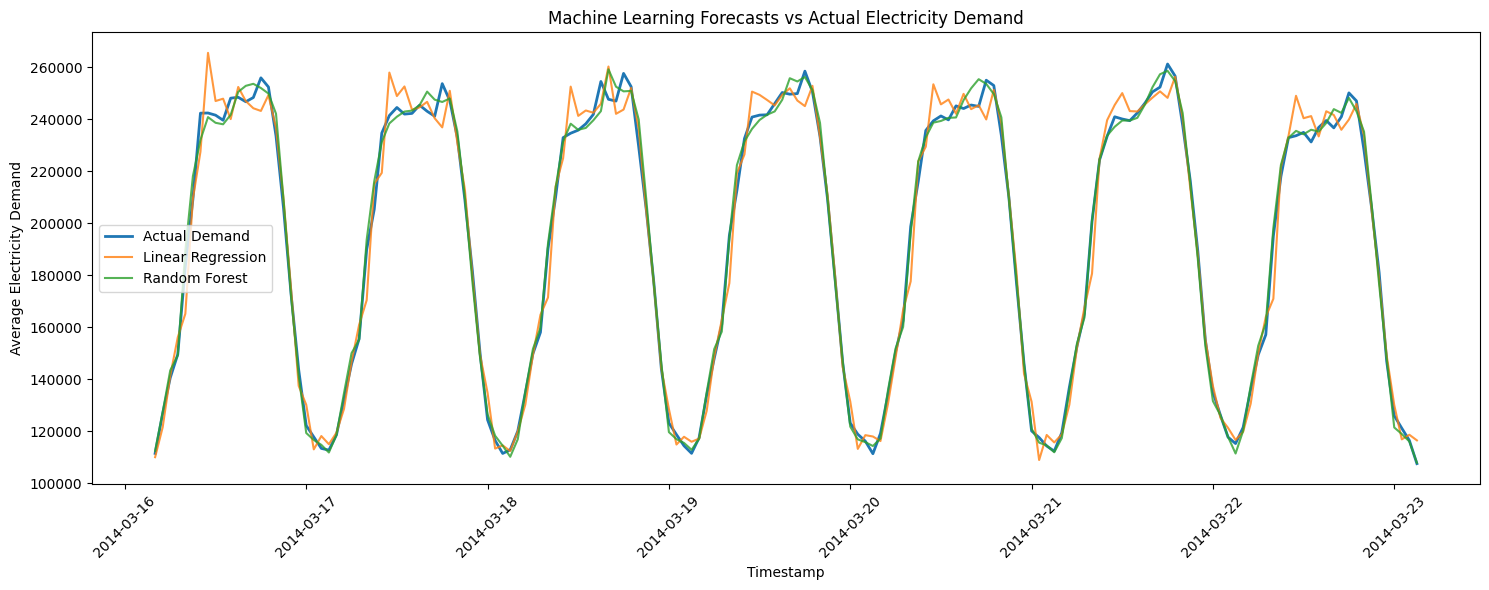

In [15]:

# Select the first 168 test observations (one week)
plot_index = y_test.index[:168]

plt.figure(figsize=(15, 6))

plt.plot(
    plot_index,
    y_test.loc[plot_index],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    plot_index,
    linear_comparison.loc[plot_index, "predicted_demand"],
    label="Linear Regression",
    alpha=0.8
)

plt.plot(
    plot_index,
    rf_comparison.loc[plot_index, "predicted_demand"],
    label="Random Forest",
    alpha=0.8
)

plt.title("Machine Learning Forecasts vs Actual Electricity Demand")
plt.xlabel("Timestamp")
plt.ylabel("Average Electricity Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:

from pathlib import Path

baseline_path = Path("../Reports/baseline_results.csv")

baseline_results = pd.read_csv(baseline_path)

print("Baseline results:")
display(baseline_results)

print("\nMachine learning results:")
display(model_results)

Baseline results:


,Model,MAE,RMSE
0,Naive Forecast,16475.717168,24779.796901
1,Seasonal Naive Forecast,8142.340185,13460.567193



Machine learning results:


,Model,MAE,RMSE
0,Linear Regression,9202.185681,13560.217163
1,Random Forest,4553.637401,6782.892398


In [17]:

# Combine the baseline and machine learning results
all_results = pd.concat(
    [baseline_results, model_results],
    ignore_index=True
)

display(all_results.sort_values("MAE").reset_index(drop=True))

,Model,MAE,RMSE
0,Random Forest,4553.637401,6782.892398
1,Seasonal Naive Forecast,8142.340185,13460.567193
2,Linear Regression,9202.185681,13560.217163
3,Naive Forecast,16475.717168,24779.796901


In [18]:

# Ensure the reports directory exists
reports_dir = Path("../Reports")
reports_dir.mkdir(parents=True, exist_ok=True)

# Save machine learning results
model_results.to_csv(
    reports_dir / "model_training_results.csv",
    index=False
)

# Save combined results
all_results.to_csv(
    reports_dir / "baseline_vs_ml_results.csv",
    index=False
)

print("Model training results saved.")
print("Combined baseline and ML results saved.")

Model training results saved.
Combined baseline and ML results saved.


In [19]:
from xgboost import XGBRegressor

## 12. Model 3 — XGBoost Regressor

Train an initial XGBoost regression model using the same
training features and chronological test period used by
Linear Regression and Random Forest.

This is an initial model configuration, not a tuned model.

In [20]:
# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [21]:
# Generate predictions for the test period
xgb_predictions = xgb_model.predict(X_test)

print("Number of predictions:", len(xgb_predictions))
print("Number of actual observations:", len(y_test))

# Compare predictions with actual demand
xgb_comparison = pd.DataFrame({
    "actual_demand": y_test,
    "predicted_demand": xgb_predictions
}, index=y_test.index)

display(xgb_comparison.head(10))

Number of predictions: 6980
Number of actual observations: 6980


,actual_demand,predicted_demand
2014-03-16 04:00:00,111525.398404,111532.812500
2014-03-16 05:00:00,126897.471138,125025.656250
2014-03-16 06:00:00,140579.737442,143555.078125
2014-03-16 07:00:00,149643.211466,149844.203125
2014-03-16 08:00:00,183540.864585,183507.281250
2014-03-16 09:00:00,209244.847104,218156.687500
2014-03-16 10:00:00,242385.296131,229662.984375
2014-03-16 11:00:00,242442.759354,243453.562500
2014-03-16 12:00:00,241607.662546,239091.531250
2014-03-16 13:00:00,239654.388901,238170.437500


## 13. Evaluate XGBoost

Evaluate the initial XGBoost model using the same MAE and RMSE
metrics and the same chronological test period used for the
previous models.

In [22]:
# Calculate XGBoost evaluation metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

print(f"XGBoost MAE:  {xgb_mae:,.2f}")
print(f"XGBoost RMSE: {xgb_rmse:,.2f}")

XGBoost MAE:  4,484.12
XGBoost RMSE: 6,611.78


In [23]:
# Add XGBoost results
model_results.loc[len(model_results)] = {
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse
}

# Sort by MAE
model_results = model_results.sort_values("MAE").reset_index(drop=True)

display(model_results)

,Model,MAE,RMSE
0,XGBoost,4484.121874,6611.778646
1,Random Forest,4553.637401,6782.892398
2,Linear Regression,9202.185681,13560.217163


In [24]:
# Combine baseline and machine learning results
all_results = pd.concat(
    [baseline_results, model_results],
    ignore_index=True
)

# Sort by MAE
all_results = all_results.sort_values("MAE").reset_index(drop=True)

display(all_results)

,Model,MAE,RMSE
0,XGBoost,4484.121874,6611.778646
1,Random Forest,4553.637401,6782.892398
2,Seasonal Naive Forecast,8142.340185,13460.567193
3,Linear Regression,9202.185681,13560.217163
4,Naive Forecast,16475.717168,24779.796901


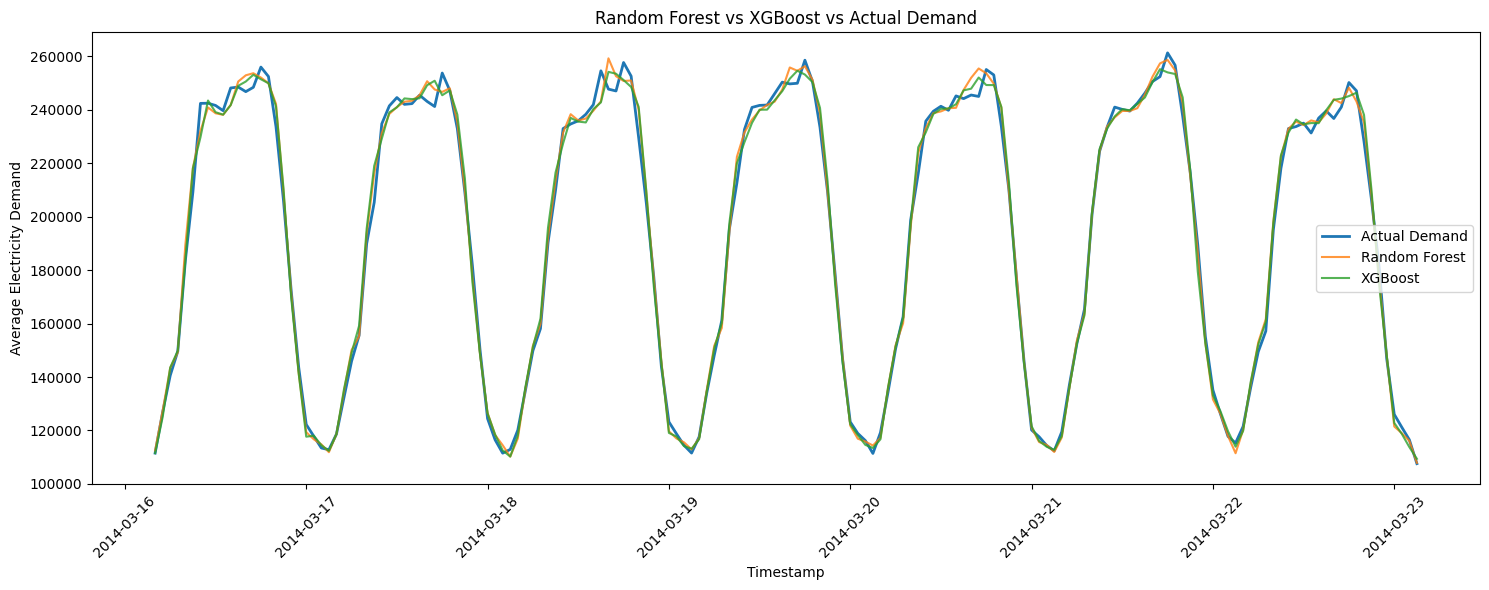

In [25]:
# Select the first 168 test observations
plot_index = y_test.index[:168]

plt.figure(figsize=(15, 6))

plt.plot(
    plot_index,
    y_test.loc[plot_index],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    plot_index,
    rf_comparison.loc[plot_index, "predicted_demand"],
    label="Random Forest",
    alpha=0.8
)

plt.plot(
    plot_index,
    xgb_comparison.loc[plot_index, "predicted_demand"],
    label="XGBoost",
    alpha=0.8
)

plt.title("Random Forest vs XGBoost vs Actual Demand")
plt.xlabel("Timestamp")
plt.ylabel("Average Electricity Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Ensure the reports directory exists
reports_dir = Path("../Reports")
reports_dir.mkdir(parents=True, exist_ok=True)

# Save all machine learning model results
model_results.to_csv(
    reports_dir / "model_training_results.csv",
    index=False
)

# Save baseline + machine learning results
all_results.to_csv(
    reports_dir / "baseline_vs_ml_results.csv",
    index=False
)

print("Updated model results saved.")
print("Updated baseline vs ML results saved.")

Updated model results saved.
Updated baseline vs ML results saved.
